# Fine-Tuning MentalRoBERTa and CLS Embedding Extraction

Fine-tune `mental/mental-roberta-base` on the 6-class mental health Reddit dataset (ADHD, Anxiety, Bipolar, Depression, PTSD, None) and extract CLS embeddings for downstream fusion models.

**Pipeline:**
1. Fine-tune with a linear classification head — best checkpoint selected by validation macro-F1
2. Evaluate the best checkpoint on the held-out test set
3. Extract CLS embeddings for all splits using `shuffle=False` so row order matches the CSV files
4. Save embeddings directly to `data/features/semantic/{split}/mental_roberta.parquet` for the fusion pipeline
5. Save the fine-tuned backbone (no classification head) to `results/models/roberta/finetuned/`

**Expected inputs:** `data/processed/{train,val,test}.csv` with columns `text`, `class_id`, `class_name`.

**Outputs:**
- Best checkpoint → `results/models/roberta/best_model/`
- Fine-tuned backbone → `results/models/roberta/finetuned/`
- CLS embeddings → `data/features/semantic/{train,val,test}/mental_roberta.parquet`
- Evaluation artifacts → `results/evaluation/roberta/`

## 1. Runtime and Dependencies

Use a GPU runtime for training speed, then install transformer and parquet dependencies.

In [1]:
!nvidia-smi

Mon May 11 14:12:25 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   55C    P8             10W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [2]:
!pip -q install transformers accelerate pandas pyarrow scikit-learn matplotlib seaborn tqdm huggingface_hub

## 2. Optional Hugging Face Login

`mental/mental-roberta-base` is a public model — login is not needed. Uncomment only if the download fails.

In [ ]:
# Optional: uncomment only if the model download fails and needs Hub authentication.
# from huggingface_hub import notebook_login
# notebook_login()

## 3. Mount Drive and Configure Paths

Set `PROJECT_DIR` to wherever you placed the `mental_health_fusion` folder in your Drive. All output paths mirror the local `scripts/config.py` layout so the fusion pipeline can load them directly.

In [4]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
from pathlib import Path

# CHANGE THIS to match wherever you placed mental_health_fusion in your Drive.
PROJECT_DIR   = Path('/content/drive/MyDrive/mental_health_fusion')
PROCESSED_DIR = PROJECT_DIR / 'data' / 'processed'
FEATURES_DIR  = PROJECT_DIR / 'data' / 'features'

# Mirrors config.ROBERTA_MODEL_DIR / config.FINETUNED_ROBERTA_DIR
CHECKPOINT_DIR      = PROJECT_DIR / 'results' / 'models' / 'roberta'
FINETUNED_MODEL_DIR = CHECKPOINT_DIR / 'finetuned'
EVAL_OUTPUT_DIR     = PROJECT_DIR / 'results' / 'evaluation' / 'roberta'

for d in [CHECKPOINT_DIR, FINETUNED_MODEL_DIR, EVAL_OUTPUT_DIR]:
    d.mkdir(parents=True, exist_ok=True)

# ── Hyperparameters ──────────────────────────────────────────────────────────
MODEL_NAME       = 'mental/mental-roberta-base'
MAX_LENGTH       = 512
BATCH_SIZE       = 16      # 16 fits comfortably on T4; use 32 on A100
EMBED_BATCH_SIZE = 32      # larger batch is fine for inference-only extraction
LEARNING_RATE    = 2e-5
NUM_EPOCHS       = 5
WEIGHT_DECAY     = 0.01
WARMUP_RATIO     = 0.1
GRAD_CLIP        = 1.0
SEED             = 42
NUM_LABELS       = 6

ID_TO_CLASS = {
    0: 'ADHD',
    1: 'Anxiety',
    2: 'Bipolar',
    3: 'Depression',
    4: 'PTSD',
    5: 'None',
}

print('Project dir        :', PROJECT_DIR)
print('Checkpoints        :', CHECKPOINT_DIR)
print('Fine-tuned backbone:', FINETUNED_MODEL_DIR)
print('Eval output        :', EVAL_OUTPUT_DIR)
print('Features dir       :', FEATURES_DIR)

## 4. Imports and Reproducibility

In [6]:
import json
import random

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
from torch.utils.data import Dataset, DataLoader
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    get_linear_schedule_with_warmup,
)
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix,
)
from tqdm.auto import tqdm


def set_seed(seed: int) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


set_seed(SEED)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')

Device: cuda


## 5. Load Data

Read train, validation, and test CSVs, then print class counts to catch label or split problems early.

In [7]:
train_df = pd.read_csv(PROCESSED_DIR / 'train.csv')
val_df   = pd.read_csv(PROCESSED_DIR / 'val.csv')
test_df  = pd.read_csv(PROCESSED_DIR / 'test.csv')

for split_name, df in [('train', train_df), ('val', val_df), ('test', test_df)]:
    dist = df['class_id'].value_counts().sort_index().rename(ID_TO_CLASS)
    print(f'{split_name} ({len(df)} rows):')
    print(dist.to_string())
    print()

train (13727 rows):
class_id
ADHD          2465
Anxiety       2422
Bipolar       2407
Depression    2450
PTSD          2001
None          1982

val (1488 rows):
class_id
ADHD          248
Anxiety       248
Bipolar       248
Depression    248
PTSD          248
None          248

test (1488 rows):
class_id
ADHD          248
Anxiety       248
Bipolar       248
Depression    248
PTSD          248
None          248



## 6. Dataset and DataLoaders

Two sets of loaders are created: training loaders (train uses `shuffle=True`) and extraction loaders (all use `shuffle=False` to preserve CSV row order).

In [8]:
class MentalHealthDataset(Dataset):
    """Tokenizes text on-the-fly; returns input_ids, attention_mask, and label."""

    def __init__(self, df: pd.DataFrame, tokenizer, max_length: int) -> None:
        self.texts  = df['text'].fillna('').astype(str).tolist()
        self.labels = df['class_id'].tolist()
        self.tok    = tokenizer
        self.maxlen = max_length

    def __len__(self) -> int:
        return len(self.texts)

    def __getitem__(self, idx: int) -> dict:
        enc = self.tok(
            self.texts[idx],
            max_length=self.maxlen,
            padding='max_length',
            truncation=True,
            return_tensors='pt',
        )
        return {
            'input_ids':      enc['input_ids'].squeeze(0),
            'attention_mask': enc['attention_mask'].squeeze(0),
            'labels':         torch.tensor(self.labels[idx], dtype=torch.long),
        }

In [ ]:
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

train_dataset = MentalHealthDataset(train_df, tokenizer, MAX_LENGTH)
val_dataset   = MentalHealthDataset(val_df,   tokenizer, MAX_LENGTH)
test_dataset  = MentalHealthDataset(test_df,  tokenizer, MAX_LENGTH)

# num_workers=0 avoids multiprocessing worker cleanup errors in Colab.
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE,       shuffle=True,  num_workers=0, pin_memory=True)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE,       shuffle=False, num_workers=0, pin_memory=True)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE,       shuffle=False, num_workers=0, pin_memory=True)

extract_train_loader = DataLoader(train_dataset, batch_size=EMBED_BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=True)
extract_val_loader   = DataLoader(val_dataset,   batch_size=EMBED_BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=True)
extract_test_loader  = DataLoader(test_dataset,  batch_size=EMBED_BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=True)

print(f'Train batches (training)   : {len(train_loader)}')
print(f'Train batches (extraction) : {len(extract_train_loader)}')
print(f'Val   batches              : {len(val_loader)}')
print(f'Test  batches              : {len(test_loader)}')

## 7. Model, Optimizer, and Scheduler

Load the sequence-classification head, configure AdamW, and create a linear warm-up schedule.

In [15]:
model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=NUM_LABELS,
    ignore_mismatched_sizes=True,   # replaces the pre-trained classification head
)
model = model.to(device)

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY,
)

total_steps  = len(train_loader) * NUM_EPOCHS
warmup_steps = int(WARMUP_RATIO * total_steps)

scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=warmup_steps,
    num_training_steps=total_steps,
)

total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Trainable parameters : {total_params:,}')
print(f'Total steps          : {total_steps}')
print(f'Warmup steps         : {warmup_steps}')

pytorch_model.bin:   0%|          | 0.00/499M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: mental/mental-roberta-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.bias                    | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
classifier.dense.bias           | MISSING    | 
classifier.out_proj.weight      | MISSING    | 
classifier.dense.weight         | MISSING    | 
classifier.out_proj.bias        | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Trainable parameters : 124,650,246
Total steps          : 4290
Warmup steps         : 429


## 8. Training and Validation Helpers

One training epoch and one evaluation pass returning loss, accuracy, macro-F1, predictions, and labels.

In [16]:
def train_epoch(model, loader, optimizer, scheduler, device):
    model.train()
    total_loss = 0.0
    all_preds, all_labels = [], []

    for batch in tqdm(loader, desc='  train', leave=False):
        input_ids      = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels         = batch['labels'].to(device)

        optimizer.zero_grad()
        outputs = model(input_ids=input_ids, attention_mask=attention_mask, labels=labels)
        outputs.loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP)
        optimizer.step()
        scheduler.step()

        total_loss += outputs.loss.item()
        all_preds.extend(outputs.logits.argmax(dim=-1).cpu().tolist())
        all_labels.extend(labels.cpu().tolist())

    avg_loss = total_loss / len(loader)
    acc = accuracy_score(all_labels, all_preds)
    f1  = f1_score(all_labels, all_preds, average='macro', zero_division=0)
    return avg_loss, acc, f1


@torch.no_grad()
def evaluate(model, loader, device):
    model.eval()
    total_loss = 0.0
    all_preds, all_labels = [], []

    for batch in tqdm(loader, desc='  eval ', leave=False):
        input_ids      = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels         = batch['labels'].to(device)

        outputs = model(input_ids=input_ids, attention_mask=attention_mask, labels=labels)
        total_loss += outputs.loss.item()
        all_preds.extend(outputs.logits.argmax(dim=-1).cpu().tolist())
        all_labels.extend(labels.cpu().tolist())

    avg_loss = total_loss / len(loader)
    acc = accuracy_score(all_labels, all_preds)
    f1  = f1_score(all_labels, all_preds, average='macro', zero_division=0)
    return avg_loss, acc, f1, all_preds, all_labels

## 9. Training Loop

Train for the configured number of epochs and save the checkpoint with the best validation macro-F1.

In [ ]:
history = {
    'train_loss': [], 'train_acc': [], 'train_f1': [],
    'val_loss':   [], 'val_acc':   [], 'val_f1':   [],
}

best_val_f1     = 0.0
best_checkpoint = CHECKPOINT_DIR / 'best_model'

for epoch in range(1, NUM_EPOCHS + 1):
    print(f'\n{"="*60}')
    print(f'Epoch {epoch}/{NUM_EPOCHS}')
    print(f'{"="*60}')

    tr_loss, tr_acc, tr_f1 = train_epoch(model, train_loader, optimizer, scheduler, device)
    va_loss, va_acc, va_f1, _, _ = evaluate(model, val_loader, device)

    history['train_loss'].append(tr_loss)
    history['train_acc'].append(tr_acc)
    history['train_f1'].append(tr_f1)
    history['val_loss'].append(va_loss)
    history['val_acc'].append(va_acc)
    history['val_f1'].append(va_f1)

    print(f'  Train  loss={tr_loss:.4f}  acc={tr_acc:.4f}  macro-F1={tr_f1:.4f}')
    print(f'  Val    loss={va_loss:.4f}  acc={va_acc:.4f}  macro-F1={va_f1:.4f}')

    if va_f1 > best_val_f1:
        best_val_f1 = va_f1
        model.save_pretrained(str(best_checkpoint))
        tokenizer.save_pretrained(str(best_checkpoint))
        print(f'  -> Best checkpoint saved  (val macro-F1 = {best_val_f1:.4f})')

print(f'\nBest validation macro-F1 : {best_val_f1:.4f}')
print(f'Checkpoint               : {best_checkpoint}')


Epoch 1/5


  train:   0%|          | 0/858 [00:00<?, ?it/s]

  eval :   0%|          | 0/93 [00:00<?, ?it/s]

  Train  loss=0.7854  acc=0.7121  macro-F1=0.7139
  Val    loss=0.4242  acc=0.8609  macro-F1=0.8615


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

  train:   0%|          | 0/858 [00:00<?, ?it/s]

  eval :   0%|          | 0/93 [00:00<?, ?it/s]

  Train  loss=0.0862  acc=0.9795  macro-F1=0.9800
  Val    loss=0.6630  acc=0.8757  macro-F1=0.8765


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

  -> Best checkpoint saved  (val macro-F1 = 0.8765)

Best validation macro-F1 : 0.8765
Checkpoint               : /content/drive/MyDrive/mental_health_projects/results/models/mental_roberta/best_model


## 10. Continue Training (Optional)

Load the best checkpoint and train for additional epochs. After running this section, re-run sections 11–16 to update curves, evaluation, and saved embeddings.

In [ ]:
# Define the number of additional epochs for continued training
ADDITIONAL_EPOCHS = 2 # You can change this value

print(f"\nContinuing training for {ADDITIONAL_EPOCHS} additional epochs...")

# Load the best model and tokenizer from the checkpoint
# This ensures we start exactly from the best checkpoint found so far
continued_model = AutoModelForSequenceClassification.from_pretrained(str(best_checkpoint))
continued_model = continued_model.to(device)
continued_tokenizer = AutoTokenizer.from_pretrained(str(best_checkpoint))

# Re-initialize optimizer and scheduler for the continued_model
# Optimizer and scheduler states are not saved with the model itself
new_optimizer = torch.optim.AdamW(
    continued_model.parameters(),
    lr=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY,
)

# Calculate total steps for the *additional* training phase
total_additional_steps = len(train_loader) * ADDITIONAL_EPOCHS
new_warmup_steps = int(WARMUP_RATIO * total_additional_steps)

new_scheduler = get_linear_schedule_with_warmup(
    new_optimizer,
    num_warmup_steps=new_warmup_steps,
    num_training_steps=total_additional_steps,
)

print(f"Total additional training steps: {total_additional_steps}")
print(f"Warmup steps for additional training: {new_warmup_steps}")

# Retrieve the best_val_f1 from the previous training run to continue tracking
current_best_val_f1 = best_val_f1

for epoch_offset in range(1, ADDITIONAL_EPOCHS + 1):
    current_epoch = NUM_EPOCHS + epoch_offset # Adjust epoch number for display
    print(f'\n{"="*60}')
    print(f'Epoch {current_epoch}/{NUM_EPOCHS + ADDITIONAL_EPOCHS} (Cont.)')
    print(f'{"="*60}')

    tr_loss, tr_acc, tr_f1 = train_epoch(continued_model, train_loader, new_optimizer, new_scheduler, device)
    va_loss, va_acc, va_f1, _, _ = evaluate(continued_model, val_loader, device)

    history['train_loss'].append(tr_loss)
    history['train_acc'].append(tr_acc)
    history['train_f1'].append(tr_f1)
    history['val_loss'].append(va_loss)
    history['val_acc'].append(va_acc)
    history['val_f1'].append(va_f1)

    print(f'  Train  loss={tr_loss:.4f}  acc={tr_acc:.4f}  macro-F1={tr_f1:.4f}')
    print(f'  Val    loss={va_loss:.4f}  acc={va_acc:.4f}  macro-F1={va_f1:.4f}')

    if va_f1 > current_best_val_f1:
        current_best_val_f1 = va_f1
        # Save the model and tokenizer to the best_checkpoint path
        continued_model.save_pretrained(str(best_checkpoint))
        continued_tokenizer.save_pretrained(str(best_checkpoint))
        print(f'  -> New best checkpoint saved during continued training (val macro-F1 = {current_best_val_f1:.4f})')

print(f'\nBest validation macro-F1 after continued training : {current_best_val_f1:.4f}')
print(f'Checkpoint for best model after continued training : {best_checkpoint}')

# Update the global best_val_f1 variable for subsequent evaluation/summary cells
best_val_f1 = current_best_val_f1

After continuing training, you should re-run the evaluation and summary cells (`cell-curves`, `cell-load-best`, `cell-report`, `cell-cm`, `cell-save`) to see the updated performance and save the new metrics and plots.

## 11. Training Curves

Plot loss, accuracy, and macro-F1 over epochs, then save the figure with the evaluation artifacts.

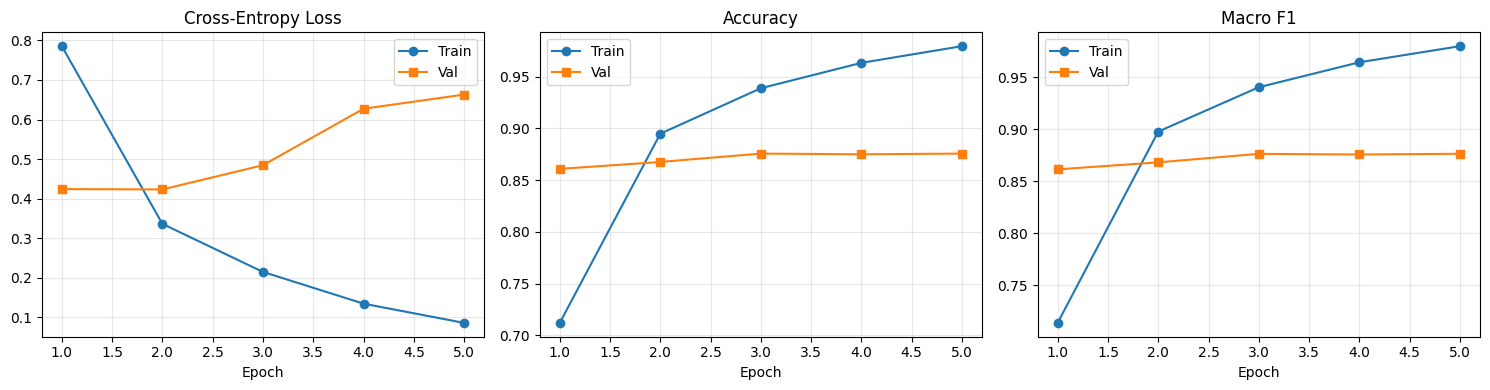

In [ ]:
epochs = range(1, NUM_EPOCHS + 1)
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, metric in zip(axes, ['loss', 'acc', 'f1']):
    ax.plot(epochs, history[f'train_{metric}'], marker='o', label='Train')
    ax.plot(epochs, history[f'val_{metric}'],   marker='s', label='Val')
    ax.set_title({'loss': 'Cross-Entropy Loss', 'acc': 'Accuracy', 'f1': 'Macro F1'}[metric])
    ax.set_xlabel('Epoch')
    ax.legend()
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(str(EVAL_OUTPUT_DIR / 'training_curves.png'), dpi=150)
plt.show()

## 12. Evaluate Best Checkpoint on Test Set

Reload the best checkpoint and evaluate it on the held-out test split.

In [17]:
# Ensure best_checkpoint is defined, useful if training loop was skipped
if 'best_checkpoint' not in globals():
    best_checkpoint = CHECKPOINT_DIR / 'best_model'

best_model = AutoModelForSequenceClassification.from_pretrained(str(best_checkpoint))
best_model = best_model.to(device)

# Ensure best_val_f1 is defined for the print statement if training loop was skipped
if 'best_val_f1' not in globals():
    # If no training was run, we cannot know the actual best_val_f1, so we set a placeholder.
    # If a summary.json exists from a previous run, you could load it here for the actual value.
    best_val_f1 = 0.0

test_loss, test_acc, test_f1, test_preds, test_labels = evaluate(best_model, test_loader, device)

print(f'Test results  (best checkpoint — val macro-F1 = {best_val_f1:.4f})')
print(f'  Loss      : {test_loss:.4f}')
print(f'  Accuracy  : {test_acc:.4f}')
print(f'  Macro-F1  : {test_f1:.4f}')

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

  eval :   0%|          | 0/93 [00:00<?, ?it/s]

Test results  (best checkpoint — val macro-F1 = 0.0000)
  Loss      : 0.5703
  Accuracy  : 0.8871
  Macro-F1  : 0.8873


## 13. Extract and Save CLS Embeddings

Extract 768-dimensional CLS embeddings for all splits using `shuffle=False` loaders so rows stay aligned with the CSV files. Embeddings are saved as `mental_roberta.parquet` directly into `data/features/semantic/{split}/` — the exact path the fusion pipeline reads. The fine-tuned backbone is also saved to `results/models/roberta/finetuned/`.

In [ ]:
@torch.no_grad()
def extract_cls(model, loader, device):
    """Extract CLS token embeddings in CSV row order.

    loader MUST use shuffle=False — row order must match the original CSV
    so embeddings align with labels when loaded by the fusion pipeline.
    """
    model.eval()
    all_embeddings = []
    for batch in tqdm(loader, desc='Extracting CLS', leave=False):
        outputs = model(
            input_ids=batch['input_ids'].to(device),
            attention_mask=batch['attention_mask'].to(device),
            output_hidden_states=True,
        )
        cls = outputs.hidden_states[-1][:, 0, :].cpu().numpy()
        all_embeddings.append(cls)
    return np.concatenate(all_embeddings, axis=0)


def save_cls_parquet(embeddings: np.ndarray, split: str) -> None:
    """Save in the pipeline-standard format: post_id + features list column."""
    out_dir = FEATURES_DIR / 'semantic' / split
    out_dir.mkdir(parents=True, exist_ok=True)
    out_path = out_dir / 'mental_roberta.parquet'
    pd.DataFrame({
        'post_id': [str(i) for i in range(len(embeddings))],
        'features': embeddings.tolist(),
    }).to_parquet(out_path, index=False)
    print(f'  Saved {split}: {out_path}  shape={embeddings.shape}')


# Resolve which model to use — continued training takes priority.
if 'continued_model' in globals() and continued_model is not None:
    embed_model = continued_model
    print('Using continued_model for extraction.')
else:
    embed_model = best_model
    print('Using best_model for extraction.')

embed_model.eval()

# Extract and save for each split using the shuffle=False extraction loaders.
for split, loader in [
    ('train', extract_train_loader),
    ('val',   extract_val_loader),
    ('test',  extract_test_loader),
]:
    print(f'Extracting {split}...')
    embeddings = extract_cls(embed_model, loader, device)
    save_cls_parquet(embeddings, split)

# Save the fine-tuned backbone (without the classification head) so the
# semantic extraction notebook can reload it via FINETUNED_MODEL_DIR.
embed_model.base_model.save_pretrained(str(FINETUNED_MODEL_DIR))
tokenizer.save_pretrained(str(FINETUNED_MODEL_DIR))
print(f'\nFine-tuned backbone saved -> {FINETUNED_MODEL_DIR}')

## 14. Per-Class Classification Report

Save and display precision, recall, F1, and support for each class.

In [ ]:
class_names = [ID_TO_CLASS[i] for i in range(NUM_LABELS)]

report_str  = classification_report(test_labels, test_preds, target_names=class_names, digits=4)
report_dict = classification_report(test_labels, test_preds, target_names=class_names,
                                    digits=4, output_dict=True)

print(report_str)

report_df = pd.DataFrame(report_dict).T
report_df.to_csv(EVAL_OUTPUT_DIR / 'classification_report.csv')
display(report_df.round(4))

              precision    recall  f1-score   support

        ADHD     0.8972    0.9153    0.9062       248
     Anxiety     0.8175    0.9032    0.8582       248
     Bipolar     0.8658    0.8065    0.8351       248
  Depression     0.8452    0.8589    0.8520       248
        PTSD     0.9110    0.8669    0.8884       248
        None     0.9959    0.9718    0.9837       248

    accuracy                         0.8871      1488
   macro avg     0.8888    0.8871    0.8873      1488
weighted avg     0.8888    0.8871    0.8873      1488



,precision,recall,f1-score,support
ADHD,0.8972,0.9153,0.9062,248.0000
Anxiety,0.8175,0.9032,0.8582,248.0000
Bipolar,0.8658,0.8065,0.8351,248.0000
Depression,0.8452,0.8589,0.8520,248.0000
PTSD,0.9110,0.8669,0.8884,248.0000
None,0.9959,0.9718,0.9837,248.0000
accuracy,0.8871,0.8871,0.8871,0.8871
macro avg,0.8888,0.8871,0.8873,1488.0000
weighted avg,0.8888,0.8871,0.8873,1488.0000


## 15. Confusion Matrix

Save both count and row-normalized confusion matrix plots for model diagnosis.

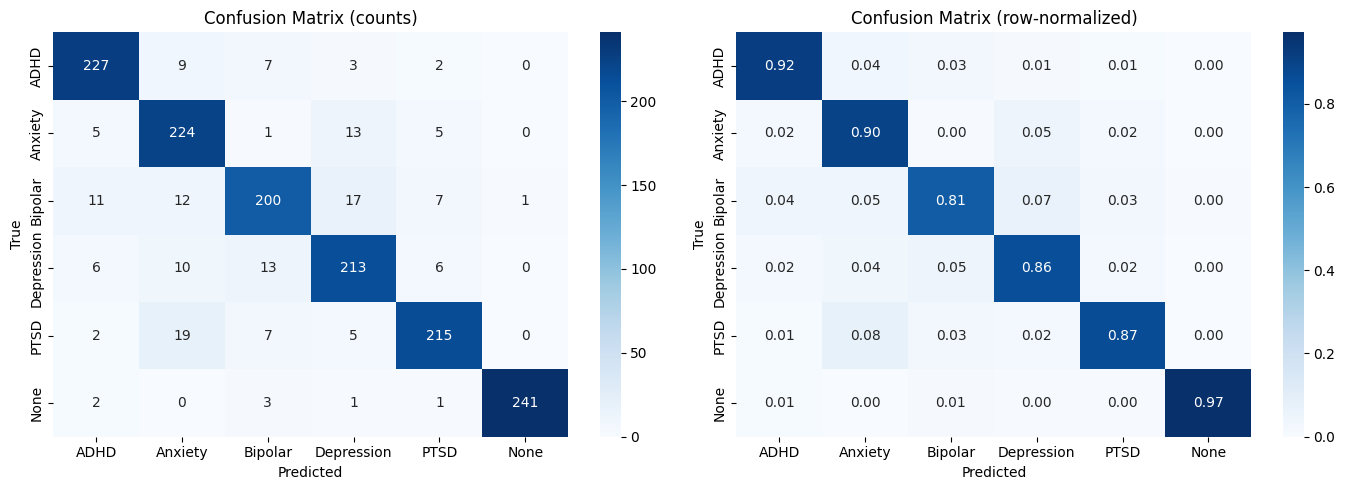

In [ ]:
cm      = confusion_matrix(test_labels, test_preds)
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names, ax=axes[0])
axes[0].set_title('Confusion Matrix (counts)')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('True')

sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names, ax=axes[1])
axes[1].set_title('Confusion Matrix (row-normalized)')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('True')

plt.tight_layout()
plt.savefig(str(EVAL_OUTPUT_DIR / 'confusion_matrix.png'), dpi=150)
plt.show()

## 16. Save Summary JSON

Write a compact JSON record with model settings, training history, best validation score, and test metrics.

In [ ]:
summary = {
    'model'             : MODEL_NAME,
    'max_length'        : MAX_LENGTH,
    'batch_size'        : BATCH_SIZE,
    'learning_rate'     : LEARNING_RATE,
    'weight_decay'      : WEIGHT_DECAY,
    'warmup_ratio'      : WARMUP_RATIO,
    'num_epochs'        : NUM_EPOCHS,
    'seed'              : SEED,
    'best_val_macro_f1' : round(best_val_f1, 6),
    'test_accuracy'     : round(test_acc, 6),
    'test_macro_f1'     : round(test_f1, 6),
    'test_loss'         : round(test_loss, 6),
    'checkpoint'        : str(best_checkpoint),
    'history'           : history,
}

summary_path = EVAL_OUTPUT_DIR / 'summary.json'
with open(summary_path, 'w') as f:
    json.dump(summary, f, indent=2)

print(f'Summary saved to : {summary_path}')
print(f'Model checkpoint : {best_checkpoint}')

Summary saved to : /content/drive/MyDrive/mental_health_projects/results/evaluation/mental_roberta/summary.json
Model checkpoint : /content/drive/MyDrive/mental_health_projects/results/models/mental_roberta/best_model


## 17. Validate Outputs

Confirm each split parquet exists, has 768-dimensional vectors, and is in the correct pipeline format.

In [ ]:
expected_rows = {'train': len(train_df), 'val': len(val_df), 'test': len(test_df)}
all_ok = True

for split in ['train', 'val', 'test']:
    path = FEATURES_DIR / 'semantic' / split / 'mental_roberta.parquet'
    if not path.exists():
        print(f'MISSING: {path}')
        all_ok = False
        continue
    df = pd.read_parquet(path)
    n_rows  = len(df)
    emb_dim = len(df['features'].iloc[0])
    row_ok  = n_rows == expected_rows[split]
    dim_ok  = emb_dim == 768
    status  = 'OK' if (row_ok and dim_ok) else 'FAIL'
    print(f'[{status}] {split}: rows={n_rows} (expected {expected_rows[split]})  dim={emb_dim}  post_id={"post_id" in df.columns}')
    if not row_ok or not dim_ok:
        all_ok = False

print()
if all_ok:
    print('All splits OK — embeddings are ready for the fusion pipeline.')
else:
    print('Some checks failed — re-run section 13 (Extract and Save CLS Embeddings).')